In [3]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [4]:
#Function 3
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 3.csv') 
columns = ['Input 1', 'Input 2', 'Input 3', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.583115, 0.709624, 0.569389,-0.04490503647909851])
data.loc[len(data)] = new_data7
#Add Week 8's data to our pandas dataframe
new_data8 = np.array([0.591817, 0.469104, 0.425630,-0.014179000315548545])
data.loc[len(data)] = new_data8
#Add Week 9's data to our pandas dataframe
new_data9 = np.array([0.435075, 0.400070, 0.435027,-0.017917485041419805])
data.loc[len(data)] = new_data9
#Add Week 10's data to our pandas dataframe
new_data10 = np.array([0.844429, 0.529216, 0.424188,-0.002260605321424087])
data.loc[len(data)] = new_data10
data

,Input 1,Input 2,Input 3,Outputs
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


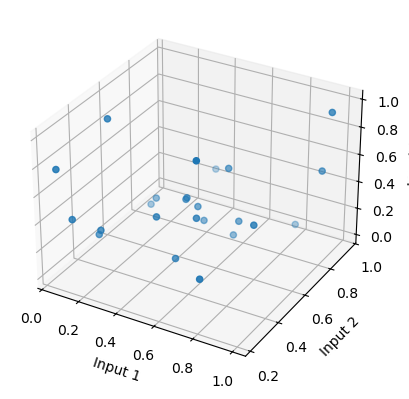

In [5]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3']])
Y = np.array(data[['Outputs']])

#Visualise already explored points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])

ax.set_xlabel("Input 1")
ax.set_ylabel("Input 2")
ax.set_zlabel("Input 3")

plt.show()

In [6]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Outputs
Input 1,1.000000,0.501700,0.036038,-0.045794
Input 2,0.501700,1.000000,-0.189940,-0.135832
Input 3,0.036038,-0.189940,1.000000,-0.531863
Outputs,-0.045794,-0.135832,-0.531863,1.000000


In [7]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)

Tuned RF Model: RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)


In [8]:
#Use latin hypercube sampling to create a grid 
d = 3
n = 20000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 500 points
n_select = 200
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [9]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)

gp.fit(X,Y)

#fit GP to candidate points suggested by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)

#fit GP to candidate points generated over the entire domain
mu_grid, std_grid = gp.predict(grid, return_std = True)

In [10]:
#Calculate UCB 
beta = 1.96#set exploration parameter
#UCB for points selected by Random forest model
UCB = mu + beta*std 
#UCB for entire domain
UCB_grid = mu_grid + beta*std_grid
#Find point selected by random forest model that maximises UCB 
X_next = X_candidates[np.argmax(UCB)]
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("Pure GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.647802 0.594053 0.42839 ]
Pure GP model next suggested point: [0.972354 0.427595 0.569977]
